## 2025-02-12

### Authors
* Nicole Tin (nicole@velexi.com)


### Ideas in this Notebook
* what can we define using CIELAB as a primary colorspace?


### Preparations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torch
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

checkpoint = "/Users/ntin/Models/sam2/checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

sam2 = build_sam2(model_cfg, checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(sam2)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

using device: cpu


In [2]:
# Dataset
dataset_name = "hawkeye-hands"

# AutoML
experiment_name = "2025-01-10_NT_hawkeye-hands-texture"
num_best_models = 5
random_seed = 42

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'
# src_dir = '/Users/nicole/Documents/DermaML_local/hawkeye-hands-2024-07-29/processed_images/'
features_dir =  '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/features-2024-08-02/'

image_folder = '/processed_images/'
csv_file = '/metadata.csv'

In [3]:
# --- Imports

# Internal library

# Standard library
import random 
# import seaborn as sns
# External packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2

# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

In [4]:
# # -- Read the CSV file
# metadata = pd.read_csv(root+ csv_file)
# metadata.loc[:, 'Age'] = 2024-metadata['birth_year']
# valid_image_fnames_df = pd.DataFrame(metadata.set_index('Age').loc[:, ['right_hand_image_file', 'left_hand_image_file']].stack()).reset_index()
# valid_image_fnames_df.columns = ['Age', 'handedness', 'filename']
# valid_image_fnames_df.loc[:,'filename'] = valid_image_fnames_df['filename'].apply(lambda x: x[:-5])
# valid_image_fnames = valid_image_fnames_df['filename'].to_numpy()

### Read Images

In [5]:
# import glob
# import os
# from pathlib import Path
# import shutil

# # External packages
# import pandas as pd
# import numpy as np
# import skimage.io

# def main(src_dir: Path,
#          dst_dir: Path, 
#          src_metadata_file: Path = "metadata.csv") -> None:
#     """
#     Prepare raw image data for feature extraction.
#     """
#     # --- Preparations

#     # Prepare destination directory
#     os.makedirs(dst_dir, exist_ok=True)

#     metadata = pd.read_csv(src_metadata_file)
#     valid_image_files_df = metadata.loc[:,['left_hand_image_file', 'right_hand_image_file']]
#     valid_image_files = valid_image_files_df.to_numpy().flatten()
#     valid_unique_image_files = np.unique(valid_image_files)

#     # Get list of image files

#     src = str(src_dir)+'/'
#     image_paths = [src + path for path in valid_unique_image_files]

#     # --- Prepare image files for feature extraction.

#     for image_path in image_paths:
#         # Load image
#         try:
#             image = skimage.io.imread(image_path)
#         except OSError:
#             print(image_path)
#             continue;

#         # # Remove background
#         # if len(image.shape) > 2:
#         #     image = remove_background(image)

#         # Save image
#         filename = os.path.basename(image_path)
#         output_path = os.path.join(dst_dir,
#                                    f"{os.path.splitext(filename)[0]}.png")
#                                 #    f"{os.path.splitext(filename)[0]}.jpeg")
#         skimage.io.imsave(output_path, image)

#     # --- Copy metadata file to dst_dir

#     shutil.copy(src_metadata_file, dst_dir)

# main(src_dir='/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/images',
#      dst_dir='/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/images_processed',
#      src_metadata_file='/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/metadata.csv')

In [ ]:
def segment_hand(img,masks):
    # use first mask by default
    hand_mask = masks[0]

    # dimensions of mask and image
    img_width, img_height = img.shape[0], img.shape[1]
    x,y,W,H = hand_mask['bbox']

    # check if mask is just whole-image
    if (
        (abs(img_width - W) <= 5) 
        & (abs(img_height - H) <= 5)
        ):
        hand_mask = masks[1]
    #FIXME: elif smaller than certain size 2000000>


    assert hand_mask['area'] > 100
    return hand_mask['segmentation']

In [ ]:
# segmentations = {}
# folder = '/images_processed/'

# dir_contents = os.listdir(root+folder)
# half_contents = sorted(dir_contents)[288:]

# for fname in tqdm(half_contents):
#     if fname == '.DS_Store':
#         continue
#     print(fname)
#     # read image
#     path = root+folder+fname
#     _img =  plt.imread(path)
#     # generate mask per image
#     masks = mask_generator.generate(_img)
#     hand = segment_hand(_img, masks)
#     assert fname[-4:]=='.png'
#     segmentations[fname[:-4]] = hand

  0%|          | 0/289 [00:00<?, ?it/s]

81d459da-0081-4dcb-b4d0-cafc5f154ca1.png


  0%|          | 0/289 [00:15<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# import pickle
# filename = '2025-02-19_Hand_Segmentations-Corrected-2.pkl'
# with open(filename, 'wb') as file:
#     pickle.dump(segmentations, file)

### Segmentation Touch Ups

In [8]:
import pickle
p_path = '/Users/ntin/Models/sam2/notebooks/'
corrected_segmentations = '2025-02-23_Hand_Segmentations-Corrected-3.pkl'
# corrected_segmentations_2 = '2025-02-19_Hand_Segmentations-Corrected-2.pkl'

with open(p_path+corrected_segmentations, 'rb') as file:
    segmentations = pickle.load(file)

# with open(p_path+corrected_segmentations_2, 'rb') as file:
#     segmentations.update(pickle.load(file))

sfnames = segmentations.keys()
sims = segmentations.values

0


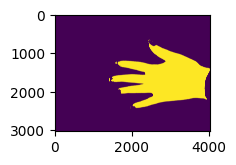

1


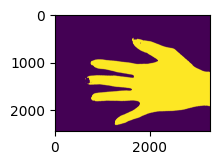

2


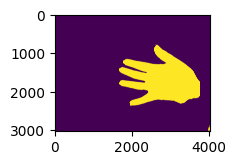

3


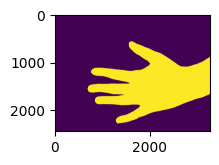

4


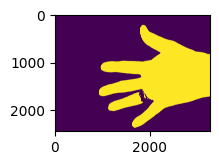

5


KeyboardInterrupt: 

In [11]:
import pickle
filename = '2025-02-22_Masks-to-Correct.pkl'
folder = '/images_processed/'

# with open(filename, 'rb') as file:
#     small_area = pickle.load(file)

small_area = list()
for key in segmentations:
    # k = key.split('.')[0]
    area = np.count_nonzero(segmentations[key])
    if area < 2500000:
        small_area.append(key)

i = 0
for k in small_area:
    print(i)
    plt.figure(figsize=(2,2))
    plt.imshow(segmentations[k])
    plt.show()
    i += 1

In [21]:
folder = '/images_processed/'

focus = ['a27a83a9-9c8a-4eef-b82b-37c9670f51ca', 'a219c403-0f79-4f82-88bc-42b99e1a0edc'][1]
# focus = small_area[17]
print(focus)
path = root+folder+focus+'.png'
_img =  plt.imread(path)
# generate / mask per image
masks = mask_generator.generate(_img)
# plt.imshow(_img)

a219c403-0f79-4f82-88bc-42b99e1a0edc


In [ ]:
# segmentations[focus] = masks[1]['segmentation']

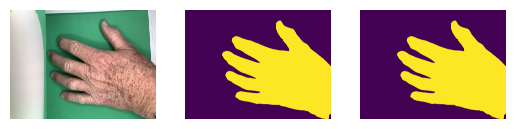

In [27]:
fig, ax = plt.subplots(ncols=3, nrows=1)
ax[0].imshow(_img)
ax[0].axis('off')

ax[1].imshow(segmentations[focus])
ax[1].axis('off')

ax[2].imshow(masks[1]['segmentation'])
ax[2].axis('off')

plt.show() 

<!--  -->

In [29]:
segmentations

{'0022f916-9391-47fc-bcee-33edfc3134da': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(3024, 4032)),
 '00991c44-a002-41f3-8c3e-40160666312f': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(3024, 3024)),
 '00daea33-42de-4664-b40b-8b07cb48f04b': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]

In [ ]:
# segmentations[focus] = ~masks[0]['segmentation']

In [28]:
import pickle
filename = '2025-02-23_Hand_Segmentations-Corrected-3.pkl'
with open(filename, 'wb') as file:
    pickle.dump(segmentations, file)

### Segmentation (SAM 2)

In [ ]:
from torchvision import transforms
# img = transforms.ToTensor()(np.array(sample_images[1]))
# img = torch.tensor(sample_images[1])
img = sample_images[1]


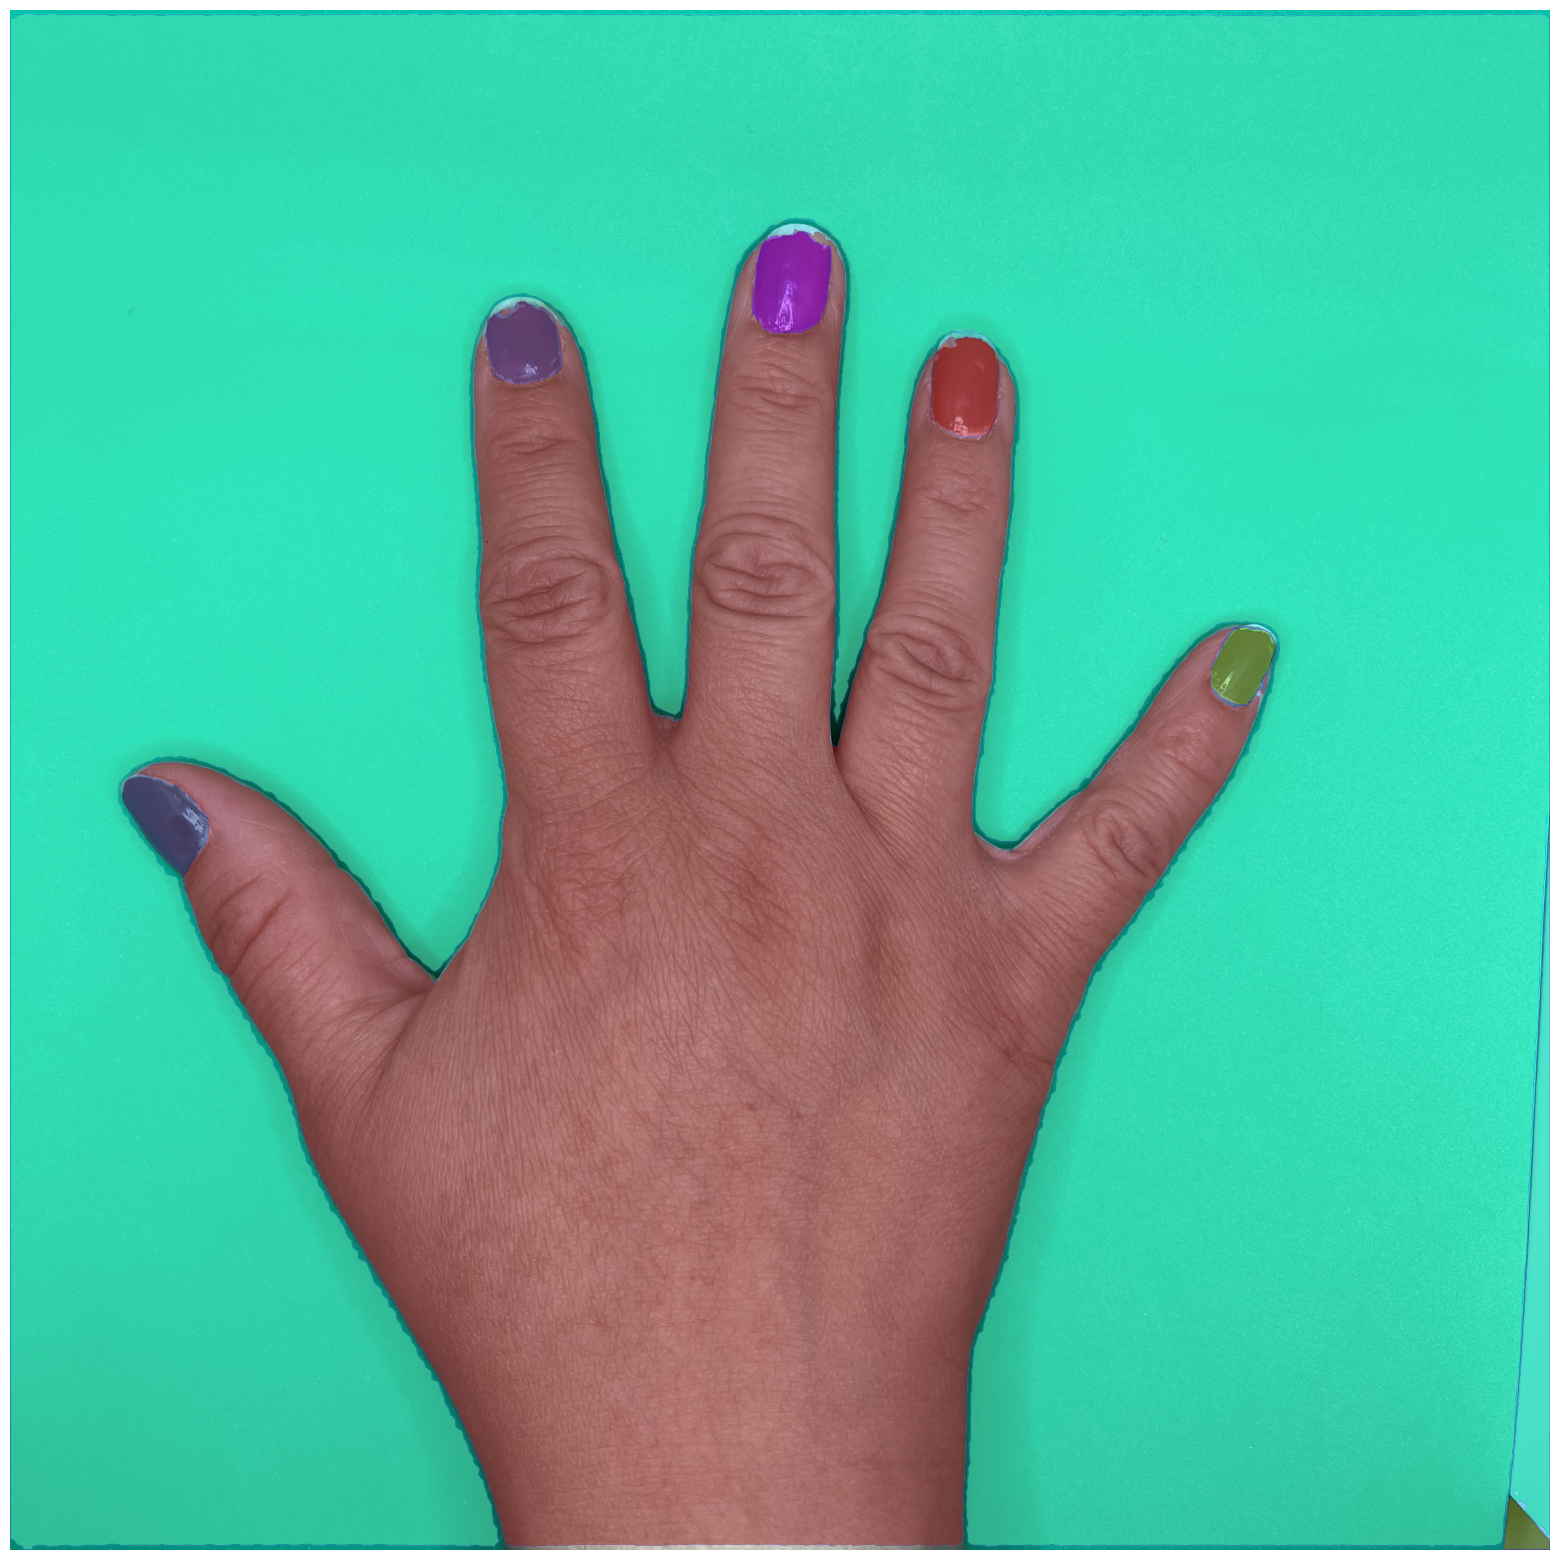

In [ ]:
plt.figure(figsize=(20, 20))
plt.imshow(img)
show_anns(masks)
plt.axis('off')
plt.show() 

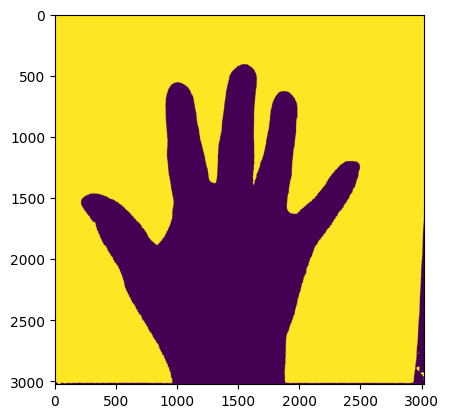

In [ ]:
plt.imshow(masks[0]['segmentation'])

### Relative Intensity in Redness

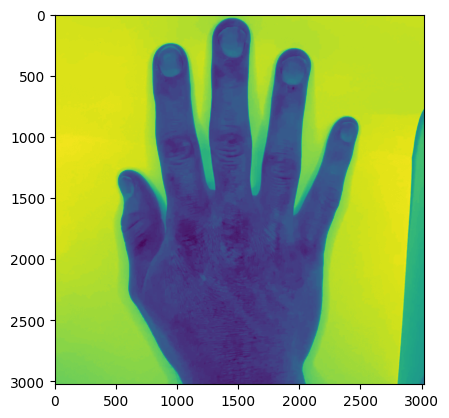

In [ ]:
plt.imshow(cv2.cvtColor(sample_images[2], cv2.COLOR_BGR2LAB)[:, :, 2])